<div style="background:linear-gradient(135deg,#4c1d95 0%,#6d28d9 55%,#a78bfa 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ddd6fe;font-weight:700;text-transform:uppercase">Chapter 196 &middot; Capstone 34 &middot; Anomaly Detection</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Finding Faults With No Labels</div>
  <div style="font-size:15px;color:#ddd6fe;max-width:820px;line-height:1.6">The first month of alerts contained two machine faults and a hundred and two data problems. Fixing three columns and excluding one operating mode was worth more than every choice of algorithm put together.</div>
</div>

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import MinCovDet
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
VI, DK, LT, MUT, GD, RD = "#6d28d9", "#4c1d95", "#a78bfa", "#94a3b8", "#047857", "#dc2626"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-anomaly-detection-unlabeled.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw   = load("Data")
notes = load("Notes")
print("rows in the export:", f"{len(raw):,}")
raw.head()

rows in the export: 8,736


,reading_id,day,minute_of_day,fill_volume_ml,cap_torque_nm,line_speed_bpm,motor_temp_c,motor_vibration_mm_s,air_pressure_bar,conveyor_current_a,ambient_temp_c,ambient_humidity_pct,filler_valve_pos_pct,reject_rate_pct,labeler_tension_n,true_state,data_issue
0,1,0,0,500.391,2.133,438.629,39.911,1.326,6.262,17.702,15.238,65.686,60.748,0.527,11.491,normal,clean
1,2,0,5,501.347,2.111,448.635,38.329,1.510,6.151,18.463,14.306,63.442,66.151,1.051,12.505,normal,clean
2,3,0,10,500.194,2.018,443.998,39.229,1.262,6.177,18.020,14.659,64.712,65.373,1.022,11.242,normal,clean
3,4,0,15,501.001,2.074,444.932,38.092,1.349,6.178,18.443,14.528,60.566,65.396,1.011,11.611,normal,clean
4,5,0,20,499.839,2.013,449.402,40.336,1.460,6.199,17.878,13.774,64.472,63.610,0.682,12.099,normal,clean


## Step 1 &middot; The brief

In [2]:
for line in notes.Notes.fillna(""):
    print(line)

CAPSTONE 34 - FINDING FAULTS WITH NO LABELS

Thirty days of five-minute telemetry from one bottling line. Twelve sensors.

THE REQUEST. Maintenance wants to be told when the line is going wrong before the
quality team finds out downstream. There is no history of labeled faults: nobody
wrote down when the line was misbehaving, which is why they are asking.

THE CONSTRAINT. One technician can investigate about FOUR alerts a day, and will stop
reading them entirely if most turn out to be nothing. There is no second chance at
this: a system that cries wolf for a fortnight gets switched off and does not come back.

WHAT A FAULT LOOKS LIKE HERE. Nothing goes out of range. A worn bearing raises
vibration AND motor temperature AND current together, each by an amount that would be
unremarkable on its own. A limit check on any single sensor will not see it.

THINGS THAT HAPPENED TO THE PLANT DURING THIS WINDOW, from the engineering log:
  day 7   a clock resync; the historian may have written so

Three things there shape everything below.

**There are no labels.** Nobody wrote down when the line was misbehaving, so there is no ROC curve to draw, no threshold to tune against a validation set, and no way to compare two detectors on accuracy. This is the ordinary situation and the whole chapter is about working inside it.

**The budget is four alerts a day**, and it is spent whether the alerts are any good or not. A system that wastes it for a fortnight gets switched off.

**The engineering log lists four things that happened to the plant** and none of them were faults. Keep that list. It turns out to matter more than the choice of algorithm.

## Step 2 &middot; Cleaning, and the first thing on the log

In [3]:
d = raw.drop_duplicates(subset=["day","minute_of_day"], keep="first").reset_index(drop=True)
print(f"raw rows                              {len(raw):,}")
print(f"after the day 7 clock resync          {len(d):,}   ({len(raw)-len(d)} readings written twice)")

F = ["fill_volume_ml","cap_torque_nm","line_speed_bpm","motor_temp_c","motor_vibration_mm_s",
     "air_pressure_bar","conveyor_current_a","ambient_temp_c","ambient_humidity_pct",
     "filler_valve_pos_pct","reject_rate_pct","labeler_tension_n"]
fault = (d.true_state != "normal").values          # the answer key, used ONLY to score
dqi   = (d.data_issue != "clean").values
print(f"\nSEALED UNTIL THE END: {fault.sum():,} readings are during a fault ({fault.mean():.1%}),")
print(f"                      {dqi.sum():,} are touched by one of the log entries ({dqi.mean():.1%}).")

raw rows                              8,736
after the day 7 clock resync          8,640   (96 readings written twice)

SEALED UNTIL THE END: 934 readings are during a fault (10.8%),
                      2,388 are touched by one of the log entries (27.6%).


## Step 3 &middot; First look

Twelve sensors and no labels, so there is nothing to check an answer against. What there is, is the shape of each sensor and the way they move together, and that is the whole basis for calling anything unusual later.

In [4]:
Z0 = (d[F].astype(float) - d[F].astype(float).mean()) / d[F].astype(float).std()
C = d[F].astype(float).corr()
out3 = (Z0.abs() > 3).any(axis=1)
pairs = sorted([(abs(C.loc[a, b]), a, b) for i, a in enumerate(F) for b in F[i+1:]], reverse=True)

A, B = "motor_vibration_mm_s", "conveyor_current_a"
resid = Z0[B] - Z0[A]*C.loc[A, B]
inlim = (Z0[A].abs() <= 3) & (Z0[B].abs() <= 3)
off = inlim & (resid.abs() > 3*resid[inlim].std())

print(f"{len(F)} sensors, {d.day.nunique()} days, one reading every "
      f"{1440//d.minute_of_day.nunique()} minutes ({len(d):,} rows)")
print(f"  no sensor ever runs away: the largest single reading anywhere is "
      f"{Z0.abs().max().max():.2f} SDs from its own mean")
print(f"  but four of them lean hard, |skew| above 1.9 "
      f"({', '.join(d[F].skew().abs().sort_values(ascending=False).head(4).index)}),")
print(f"  so plus or minus 3 SDs catches {out3.sum():,} readings, {out3.mean():.1%} of the month, "
      f"about {out3.sum()/d.day.nunique():.0f} alerts a day against a budget of four")
print(f"  the motor sensors move as a group, up to {pairs[0][0]:.3f}, and {int(off.sum())} readings "
      f"break the {A} / {B} relationship")
print( "  while sitting inside the limits on both. A limit check cannot see any of those.")

12 sensors, 30 days, one reading every 5 minutes (8,640 rows)
  no sensor ever runs away: the largest single reading anywhere is 4.94 SDs from its own mean
  but four of them lean hard, |skew| above 1.9 (air_pressure_bar, line_speed_bpm, conveyor_current_a, motor_temp_c),
  so plus or minus 3 SDs catches 913 readings, 10.6% of the month, about 30 alerts a day against a budget of four
  the motor sensors move as a group, up to 0.991, and 111 readings break the motor_vibration_mm_s / conveyor_current_a relationship
  while sitting inside the limits on both. A limit check cannot see any of those.


**What this shows.** No sensor ever runs away. The largest single reading anywhere in the month is under five standard deviations from its own mean, and the interquartile ranges are tight. Read only the medians and this plant looks fine for thirty days.

Now read the skew and kurtosis columns. Line speed, motor temperature, vibration and conveyor current all lean hard to one side, which is what a machine that stops overnight looks like. Because of that lean, plus or minus three standard deviations is not the rare event the phrase suggests: it catches about a tenth of all readings, roughly thirty alerts a day against a budget of four.

The last two blocks are the ones that matter. The motor sensors move as a group, above 0.93 with each other, and more than a hundred readings sit comfortably inside the limits on both vibration and current while breaking the relationship between them. A limit check cannot see those at all.

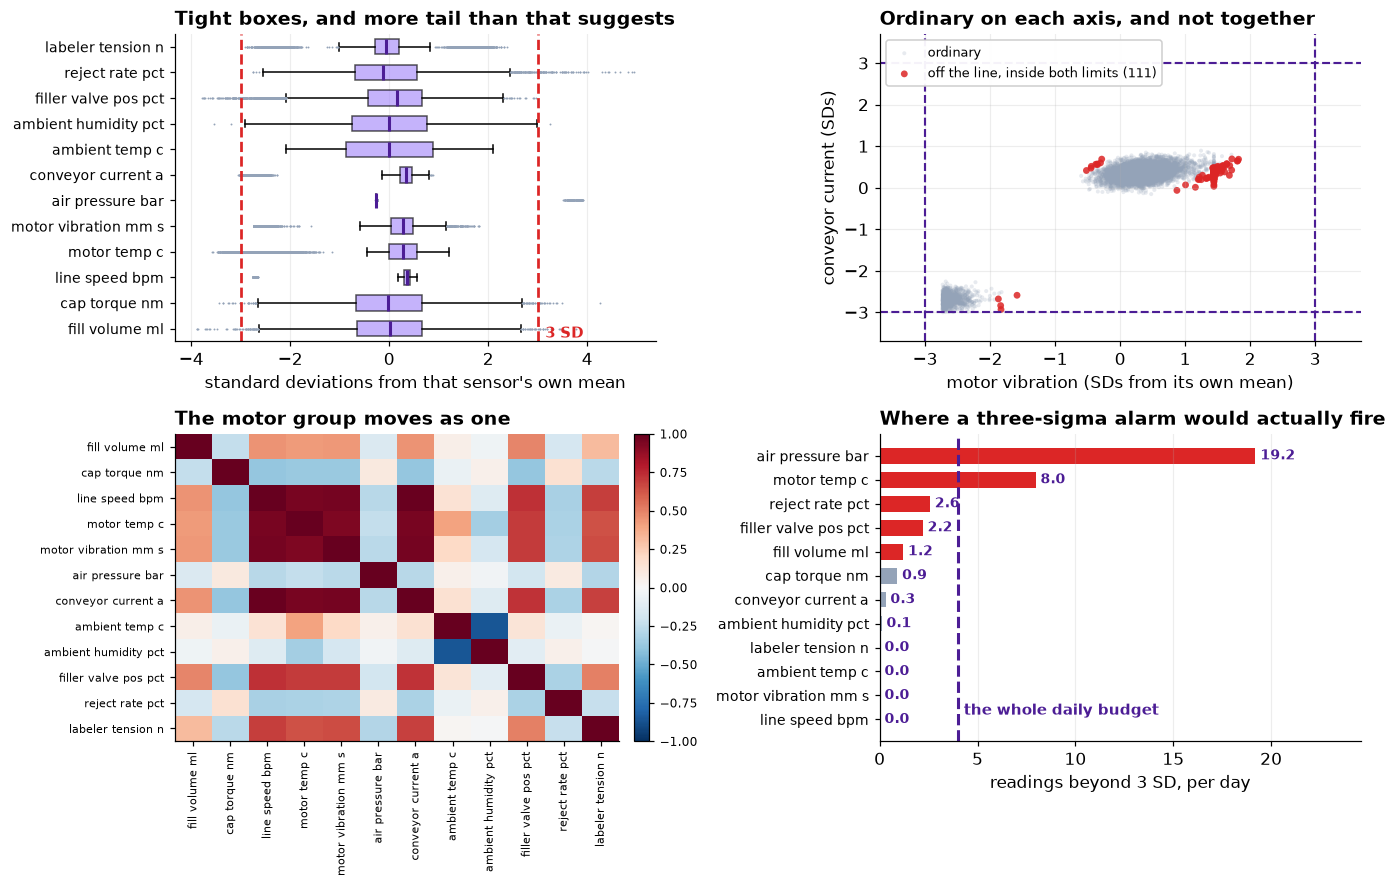

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.2))

ax = axes[0, 0]
bp = ax.boxplot([Z0[f].values for f in F], vert=False, patch_artist=True, widths=0.6,
                showfliers=True, flierprops=dict(marker=".", markersize=2.5,
                markerfacecolor=MUT, markeredgecolor="none"),
                tick_labels=[f.replace("_", " ") for f in F])
for patch in bp["boxes"]:
    patch.set_facecolor(LT); patch.set_alpha(0.65)
for m_ in bp["medians"]:
    m_.set_color(DK); m_.set_linewidth(2)
for k in (-3, 3):
    ax.axvline(k, color=RD, lw=1.8, ls="--")
ax.text(3.15, 0.65, "3 SD", color=RD, fontsize=9.5, fontweight="bold")
ax.set_xlabel("standard deviations from that sensor's own mean")
ax.set_title("Tight boxes, and more tail than that suggests")
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="y", alpha=0)

ax = axes[0, 1]
ax.scatter(Z0[A][inlim & ~off], Z0[B][inlim & ~off], s=7, alpha=0.22, color=MUT,
           edgecolor="none", label="ordinary")
ax.scatter(Z0[A][off], Z0[B][off], s=20, alpha=0.85, color=RD, edgecolor="none",
           label=f"off the line, inside both limits ({int(off.sum()):,})")
for k in (-3, 3):
    ax.axvline(k, color=DK, lw=1.4, ls="--"); ax.axhline(k, color=DK, lw=1.4, ls="--")
ax.set_xlim(-3.7, 3.7); ax.set_ylim(-3.7, 3.7)
ax.set_xlabel("motor vibration (SDs from its own mean)")
ax.set_ylabel("conveyor current (SDs)")
ax.set_title("Ordinary on each axis, and not together")
ax.legend(fontsize=8.5, loc="upper left", framealpha=0.95)

ax = axes[1, 0]
im = ax.imshow(C.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
lbl = [f.replace("_", " ") for f in F]
ax.set_xticks(range(len(F))); ax.set_xticklabels(lbl, fontsize=7.5, rotation=90)
ax.set_yticks(range(len(F))); ax.set_yticklabels(lbl, fontsize=7.5)
ax.set_title("The motor group moves as one")
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03).ax.tick_params(labelsize=8)

ax = axes[1, 1]
per = ((Z0.abs() > 3).sum()/d.day.nunique()).sort_values()
cols = [RD if v >= 1 else MUT for v in per.values]
ax.barh(range(len(per)), per.values, color=cols, height=0.66)
ax.set_yticks(range(len(per)))
ax.set_yticklabels([f.replace("_", " ") for f in per.index], fontsize=9)
for i, v_ in enumerate(per.values):
    ax.text(v_ + 0.25, i, f"{v_:.1f}", va="center", fontsize=9, fontweight="bold", color=DK)
ax.axvline(4, color=DK, lw=2.0, ls="--")
ax.text(4.3, 0.2, "the whole daily budget", color=DK, fontsize=9.5, fontweight="bold")
ax.set_xlim(0, max(per.values)*1.28)
ax.set_xlabel("readings beyond 3 SD, per day")
ax.set_title("Where a three-sigma alarm would actually fire")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**Top left:** the boxes are narrow and the dashed lines at plus and minus three standard deviations look like a reasonable alarm until you count what falls outside them. On sensors this skewed, that threshold is not rare, which is what Step 4 measures in alerts per day. **Top right:** the two motor sensors normally sit on a tight diagonal. The marked points break it while staying inside the dashed box on both axes, so no single-sensor limit will ever fire on them.

**Bottom left:** the whole correlation matrix. One warm block dominates it, the four motor sensors, and everything else is close to independent. **Bottom right:** where a three-sigma alarm would actually fire, per day. Air pressure alone would fire nineteen times a day and motor temperature eight, so between them they spend five times the entire budget before any other sensor is counted. That is what a skewed distribution does to a symmetric rule. Almost none of it would be a fault.

Finding the readings in the top right without labels, and inside four alerts a day, is the rest of this notebook.

## Step 4 &middot; Why a limit check will not do

The obvious first system is a limit on each sensor. Alert when anything goes more than three standard deviations from its mean.

In [6]:
X = d[F].values.astype(float)
z = np.abs((X - X.mean(0))/X.std(0))
for k in [3, 4]:
    a = (z > k).any(1)
    print(f"plus or minus {k} standard deviations on any sensor")
    print(f"   {a.sum():,} alerts, {a.sum()/30:.1f} a day")
    print(f"   catches {(a & fault).sum():,} of {fault.sum():,} fault readings ({(a & fault).sum()/fault.sum():.1%})")
    print(f"   precision {(a & fault).sum()/max(a.sum(),1):.1%}\n")

plus or minus 3 standard deviations on any sensor
   913 alerts, 30.4 a day
   catches 67 of 934 fault readings (7.2%)
   precision 7.3%

plus or minus 4 standard deviations on any sensor
   11 alerts, 0.4 a day
   catches 4 of 934 fault readings (0.4%)
   precision 36.4%



At three standard deviations it produces 30 alerts a day, seven times the budget, and finds 7 percent of the fault readings. At four it produces less than one alert a day and finds under half a percent.

The reason is in the brief. **A worn bearing raises vibration and motor temperature and current together**, each by an amount that is unremarkable on its own. Nothing goes out of range. The information is entirely in the combination, which is what a multivariate detector is for.

## Step 5 &middot; Three detectors, and what a month of alerts buys

Three standard methods, three quite different ideas about what "unusual" means.

- **Isolation forest** builds random trees and scores a point by how few splits it takes to isolate it. Points in sparse regions are isolated quickly.
- **Local outlier factor** compares a point's local density with the density of its neighbours. It is relative, so a point far from the bulk but surrounded by similar points is not an outlier.
- **Robust Mahalanobis distance** fits a covariance matrix resistant to contamination and measures distance in units of that covariance. It is the one that directly notices when correlated sensors stop agreeing.

The technician can look at four a day, so give each of them exactly 120 alerts for the month.

In [7]:
Z = StandardScaler().fit_transform(X)
CAP = 4*30
def topk(s, k=CAP): return s >= np.sort(s)[-k]

iso = IsolationForest(n_estimators=400, random_state=1).fit(Z)
s_iso = -iso.score_samples(Z)
lof = LocalOutlierFactor(n_neighbors=35); lof.fit_predict(Z)
s_lof = -lof.negative_outlier_factor_
s_rob = MinCovDet(random_state=1).fit(Z).mahalanobis(Z)

print(f"TOP {CAP} ALERTS ON THE EXPORT AS DELIVERED")
print(f"  {'detector':24s} {'machine faults':>15s} {'data problems':>15s} {'neither':>9s}")
for nm, s in [("isolation forest", s_iso), ("local outlier factor", s_lof),
              ("robust Mahalanobis", s_rob)]:
    a = topk(s)
    print(f"  {nm:24s} {(a & fault).sum():15d} {(a & dqi).sum():15d} {(a & ~fault & ~dqi).sum():9d}")

TOP 120 ALERTS ON THE EXPORT AS DELIVERED
  detector                  machine faults   data problems   neither
  isolation forest                       2             102        16
  local outlier factor                  46              32        49
  robust Mahalanobis                     0             120         0


In [8]:
print("what the isolation forest actually sent the technician:")
print(d.loc[topk(s_iso), "data_issue"].value_counts().to_string())

what the isolation forest actually sent the technician:
data_issue
unit_change_psi       90
clean                 18
calibration_offset    12


**Two machine faults and a hundred and two data problems.** Ninety of the alerts are the air pressure transmitter reporting in psi after its firmware update, and the technician spends the month confirming, ninety times, that a firmware update happened on day 12.

The robust Mahalanobis distance does worse still: **zero faults**, 120 data problems.

Local outlier factor is the exception and the reason is worth understanding. The 576 psi readings are a long way from the bulk of the data, so a global method sees 576 extreme points. LOF asks a local question instead, and each psi reading sits in a perfectly ordinary neighbourhood of 575 other psi readings. **It is not that LOF is smarter. It is asking a different question, and on this particular defect the different question happens to be the better one.**

## Step 6 &middot; The detectors do not agree with each other

In [9]:
S = {"isolation forest": set(np.where(topk(s_iso))[0]),
     "local outlier factor": set(np.where(topk(s_lof))[0]),
     "robust Mahalanobis": set(np.where(topk(s_rob))[0])}
ks = list(S)
for i in range(3):
    for j in range(i+1, 3):
        a, b = S[ks[i]], S[ks[j]]
        print(f"  {ks[i]:22s} vs {ks[j]:22s}  {len(a & b):3d} of 120 in common")
print(f"\n  flagged by all three: {len(S[ks[0]] & S[ks[1]] & S[ks[2]])} of 120")

  isolation forest       vs local outlier factor     10 of 120 in common
  isolation forest       vs robust Mahalanobis       45 of 120 in common
  local outlier factor   vs robust Mahalanobis        4 of 120 in common

  flagged by all three: 4 of 120


Three well-regarded detectors, the same data, the same budget, and they agree on four readings out of a hundred and twenty.

With labels this would be easy to adjudicate. Without them, there is no basis for preferring one list to another, which is uncomfortable and is the honest position. It also suggests a way forward that section 8 comes back to: if they disagree this much, the readings they agree on are worth something.

## Step 7 &middot; Repair the data, using the engineering log

Every entry in the log is visible in the data if you look for it.

In [10]:
e = d.copy()
m = e.air_pressure_bar > 20
print("DAY 12, FIRMWARE UPDATE")
print(f"  {m.sum():,} readings above 20 in a column whose unit is bar.")
print(f"  median {e.loc[m,'air_pressure_bar'].median():.1f} against {e.loc[~m,'air_pressure_bar'].median():.2f} elsewhere, "
      f"a factor of {e.loc[m,'air_pressure_bar'].median()/e.loc[~m,'air_pressure_bar'].median():.2f}.")
print("  1 bar = 14.5038 psi. Converted.")
e.loc[m, "air_pressure_bar"] = e.loc[m, "air_pressure_bar"]/14.5038

stuck = e.motor_vibration_mm_s.rolling(6).std().fillna(1) == 0
print(f"\nDAY 19, SENSOR 'NOT UPDATING'")
print(f"  {stuck.sum()} readings where vibration is identical for six consecutive samples.")
print("  A stuck sensor carries no information about the machine. Dropped.")

pre  = e.loc[e.day < 24,  "labeler_tension_n"].median()
post = e.loc[e.day >= 24, "labeler_tension_n"].median()
print(f"\nDAY 24, LABELER RECALIBRATED")
print(f"  median tension {pre:.2f} N before, {post:.2f} N after: a step of {post-pre:+.2f} N.")
print("  A recalibration changes the scale, not the machine. Re-levelled.")
e.loc[e.day >= 24, "labeler_tension_n"] -= (post - pre)

e = e[~stuck].reset_index(drop=True)
print(f"\nreadings remaining: {len(e):,}")

DAY 12, FIRMWARE UPDATE
  576 readings above 20 in a column whose unit is bar.
  median 90.8 against 6.20 elsewhere, a factor of 14.63.
  1 bar = 14.5038 psi. Converted.

DAY 19, SENSOR 'NOT UPDATING'
  79 readings where vibration is identical for six consecutive samples.
  A stuck sensor carries no information about the machine. Dropped.

DAY 24, LABELER RECALIBRATED
  median tension 11.75 N before, 14.09 N after: a step of +2.34 N.
  A recalibration changes the scale, not the machine. Re-levelled.

readings remaining: 8,561


## Step 8 &middot; Now define what normal means

In [11]:
f2 = (e.true_state != "normal").values
X2 = e[F].values.astype(float)
Z2 = StandardScaler().fit_transform(X2)
iso2 = IsolationForest(n_estimators=400, random_state=1).fit(Z2)
si2 = -iso2.score_samples(Z2)
a2 = si2 >= np.sort(si2)[-CAP]
print(f"isolation forest, top {CAP} after the repairs: {(a2 & f2).sum()} machine faults")
print()
print(f"  median line speed among the alerts        {e.loc[a2,'line_speed_bpm'].median():7.1f} bottles per minute")
print(f"  median line speed among everything else   {e.loc[~a2,'line_speed_bpm'].median():7.1f}")
print(f"  share of alerts with the line stopped     {(e.loc[a2,'line_speed_bpm'] < 100).mean():7.1%}")
print(f"  share of the file with the line stopped   {(e.line_speed_bpm < 100).mean():7.1%}")

isolation forest, top 120 after the repairs: 5 machine faults

  median line speed among the alerts            6.0 bottles per minute
  median line speed among everything else     447.4
  share of alerts with the line stopped      100.0%
  share of the file with the line stopped     12.1%


Every single alert is the line being stopped.

The detector is not wrong. A stopped line genuinely is unusual: the speed is near zero, the motor cools toward ambient, vibration falls to a background hum. It is about twelve percent of the readings and it is a completely different operating mode from a line running at 448 bottles a minute.

It is also not a fault, and nobody needs to be told about it. **An anomaly detector answers "is this unlike the rest of the data", and the question that was wanted is "is this unlike normal operation".** Those coincide only if the dataset contains nothing but normal operation, which it never does.

The fix is to say what normal means and restrict to it.

In [12]:
run = (e.line_speed_bpm > 100).values
g = e[run].reset_index(drop=True)
f3 = (g.true_state != "normal").values
X3 = g[F].values.astype(float)
Z3 = StandardScaler().fit_transform(X3)
print(f"{run.sum():,} readings with the line running, of which {f3.sum():,} are faults ({f3.mean():.1%})")

si3 = -IsolationForest(n_estimators=400, random_state=1).fit(Z3).score_samples(Z3)
l3  = LocalOutlierFactor(n_neighbors=35); l3.fit_predict(Z3); sl3 = -l3.negative_outlier_factor_
sr3 = MinCovDet(random_state=1).fit(Z3).mahalanobis(Z3)
def top3(s, k=CAP): return s >= np.sort(s)[-k]

print(f"\nTOP {CAP} ALERTS, DATA REPAIRED AND RESTRICTED TO RUNNING OPERATION")
print(f"  {'detector':24s} {'faults':>8s} {'precision':>11s} {'lift over the base rate':>25s}")
for nm, s in [("isolation forest", si3), ("local outlier factor", sl3), ("robust Mahalanobis", sr3)]:
    a = top3(s)
    print(f"  {nm:24s} {(a & f3).sum():8d} {(a & f3).sum()/CAP:11.1%} "
          f"{((a & f3).sum()/CAP)/f3.mean():24.1f}x")

7,529 readings with the line running, of which 907 are faults (12.0%)



TOP 120 ALERTS, DATA REPAIRED AND RESTRICTED TO RUNNING OPERATION
  detector                   faults   precision   lift over the base rate
  isolation forest               51       42.5%                      3.5x
  local outlier factor           71       59.2%                      4.9x
  robust Mahalanobis            102       85.0%                      7.1x


From two useful alerts in a month to a hundred and two.

The ordering of the three has also reversed. On the raw export the robust Mahalanobis distance was the worst of the three, finding nothing at all; on repaired data restricted to one operating mode it is by a distance the best, at **85 percent precision**. That is not luck. The faults in this dataset are correlated sensors ceasing to agree with each other, and a Mahalanobis distance measures exactly that. Once the two things that were breaking the covariance estimate are gone, it has the right tool for the job.

The general point is worth stating plainly. **Cleaning the data and defining the operating mode moved precision from under two percent to eighty-five. No choice among the three algorithms moved it anywhere near that far.**

## Step 9 &middot; Setting a threshold with nothing to tune against

There is no validation set, so the threshold cannot be optimized. It can be chosen, and the thing to choose it against is the technician's capacity.

First, the metric has to change. Maintenance does not care about individual five-minute readings; it cares about being told, once, that an episode is under way.

In [13]:
st = g.true_state.values
epi = np.zeros(len(g), dtype=int); k = 0
for i in range(len(g)):
    if st[i] != "normal" and (i == 0 or st[i-1] != st[i]): k += 1
    epi[i] = k if st[i] != "normal" else 0
n_epi = epi.max()
print(f"{n_epi} distinct fault episodes in the running data")
print(f"  {'budget':>22s} {'alerts':>8s} {'per day':>9s} {'precision':>11s} {'episodes caught':>17s}")
for k_ in [30, 60, 120, 240, 480]:
    a = top3(sr3, k_)
    print(f"  {'top ' + str(k_):>22s} {k_:8d} {k_/30:9.1f} {(a & f3).sum()/k_:11.1%} "
          f"{len(set(epi[a]) - {0}):9d} of {n_epi}")

23 distinct fault episodes in the running data
                  budget   alerts   per day   precision   episodes caught
                  top 30       30       1.0      100.0%        16 of 23
                  top 60       60       2.0       91.7%        19 of 23
                 top 120      120       4.0       85.0%        20 of 23
                 top 240      240       8.0       77.5%        23 of 23
                 top 480      480      16.0       59.0%        23 of 23


That table is the conversation to have with the maintenance manager, and it does not require anybody to understand the algorithm.

One alert a day is right every time and misses seven episodes in a month. Eight a day catches all twenty-three and is wrong nearly a quarter of the time. Four a day, which is what they said they could handle, gets twenty of twenty-three at 85 percent precision.

**The threshold is an operations decision presented as a table, not a statistical one presented as a number.**

Second, use the disagreement from section 5. If three detectors overlap this little, the readings all of them dislike are unusual in more than one sense.

In [14]:
vote = top3(si3).astype(int) + top3(sl3).astype(int) + top3(sr3).astype(int)
print(f"  {'policy':32s} {'alerts':>8s} {'per day':>9s} {'precision':>11s} {'episodes':>15s}")
for v, nm in [(1, "any one of the three"), (2, "at least two of the three"), (3, "all three agree")]:
    m = vote >= v
    print(f"  {nm:32s} {m.sum():8d} {m.sum()/30:9.1f} {(m & f3).sum()/max(m.sum(),1):11.1%} "
          f"{len(set(epi[m]) - {0}):7d} of {n_epi}")

  policy                             alerts   per day   precision        episodes
  any one of the three                  238       7.9       55.0%      22 of 23
  at least two of the three              90       3.0       72.2%      22 of 23
  all three agree                        32       1.1       87.5%      15 of 23


**Two of three is the policy to ship.** Ninety alerts over the month, three a day, comfortably inside the budget, 72 percent of them real, and it catches twenty-two of the twenty-three episodes.

Requiring all three agree is more accurate per alert and misses a third of the episodes, because the three detectors are looking for different things and only the most blatant faults look wrong in all three ways at once.

In [15]:
a = top3(sr3)
print("WHICH FAULT TYPES GET MISSED, best single detector at four alerts a day")
for t in ["bearing_wear", "valve_drift", "air_leak"]:
    tot = len(set(epi[st == t]) - {0}); got = len(set(epi[a & (st == t)]) - {0})
    print(f"  {t:14s} {got} of {tot} episodes")

WHICH FAULT TYPES GET MISSED, best single detector at four alerts a day
  bearing_wear   9 of 9 episodes
  valve_drift    8 of 8 episodes
  air_leak       3 of 6 episodes


The air leak is the hard one, and it is worth knowing which failure mode the system is weak on before it is switched on rather than after it misses one.

## Step 10 &middot; Measuring sensitivity without any labels

Everything scored so far used the answer key. In practice there isn't one, and the question "how big does a fault have to be before this notices" still needs an answer.

It can be answered by **injection**: take the clean data, add a fault of known size and shape, and see whether the detector catches it. This uses no labels, it can be run against production data every month, and it is the only sensitivity figure that is actually available.

In [16]:
rs = np.random.default_rng(12)
def inject(strength, reps=12, L=40):
    hits = []
    for _ in range(reps):
        h = g.copy()
        s0 = int(rs.integers(100, len(h) - 100)); idx = np.arange(s0, s0 + L)
        ramp = np.linspace(0, 1, L)*strength
        h.loc[idx, "motor_vibration_mm_s"] += 0.42*ramp
        h.loc[idx, "motor_temp_c"]         += 2.60*ramp
        h.loc[idx, "conveyor_current_a"]   += 0.55*ramp
        Zh = StandardScaler().fit_transform(h[F].values.astype(float))
        sh = MinCovDet(random_state=1).fit(Zh).mahalanobis(Zh)
        hits.append(bool((sh >= np.sort(sh)[-CAP])[idx].any()))
    return float(np.mean(hits))

print("synthetic bearing-wear episodes injected into the clean data")
print(f"  {'severity':>12s} {'caught':>9s}")
for s_ in [0.4, 0.7, 1.0]:
    print(f"  {s_:11.0%} {inject(s_):9.0%}")

synthetic bearing-wear episodes injected into the clean data
      severity    caught


          40%       42%


          70%       75%


         100%      100%


At full severity the detector catches the injected episode every time. At forty percent of it, roughly two in five. That is a real answer to "how bad does it have to get before we hear about it", and it was obtained without a single labeled fault.

Repeat this monthly against live data and it also becomes a monitoring check: if the injected-fault detection rate falls, something about the line or the sensors has changed and the detector needs refitting.

## Step 11 &middot; The answer key, and what it confirms

In [17]:
print("WHAT WAS ACTUALLY IN THE FILE")
print(d.true_state.value_counts().to_string())
print()
print(d.data_issue.value_counts().to_string())
print(f"\n{dqi.sum():,} of {len(d):,} readings ({dqi.mean():.1%}) were touched by something in the "
      "engineering log,")
print(f"against {fault.sum():,} ({fault.mean():.1%}) touched by an actual fault.")
print("\nThe data problems outnumbered the faults more than two to one, and they were louder.")

WHAT WAS ACTUALLY IN THE FILE
true_state
normal          7706
bearing_wear     368
valve_drift      360
air_leak         206

data_issue
clean                 6252
calibration_offset    1728
unit_change_psi        576
stuck_sensor            84

2,388 of 8,640 readings (27.6%) were touched by something in the engineering log,
against 934 (10.8%) touched by an actual fault.

The data problems outnumbered the faults more than two to one, and they were louder.


## Step 12 &middot; The pictures

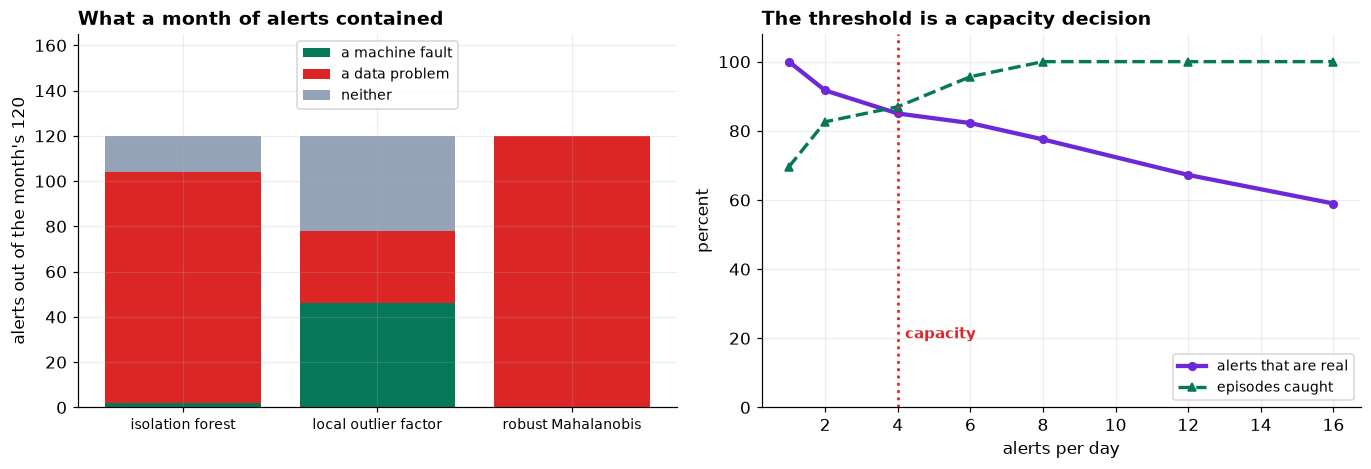

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
names = ["isolation forest", "local outlier factor", "robust Mahalanobis"]
fa = [(topk(s) & fault).sum() for s in (s_iso, s_lof, s_rob)]
dp = [(topk(s) & dqi).sum()   for s in (s_iso, s_lof, s_rob)]
ne = [CAP - a - b for a, b in zip(fa, dp)]
xp = np.arange(3)
ax.bar(xp, fa, color=GD, label="a machine fault")
ax.bar(xp, dp, bottom=fa, color=RD, label="a data problem")
ax.bar(xp, ne, bottom=np.array(fa)+np.array(dp), color=MUT, label="neither")
ax.set_xticks(xp); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel("alerts out of the month's 120")
ax.set_title("What a month of alerts contained")
ax.legend(fontsize=9, loc="upper center")
ax.set_ylim(0, 165)

ax = axes[1]
budgets = [30, 60, 120, 180, 240, 360, 480]
prec = [(top3(sr3, b) & f3).sum()/b*100 for b in budgets]
rec  = [len(set(epi[top3(sr3, b)]) - {0})/n_epi*100 for b in budgets]
ax.plot([b/30 for b in budgets], prec, color=VI, lw=2.8, marker="o", ms=5, label="alerts that are real")
ax.plot([b/30 for b in budgets], rec,  color=GD, lw=2.2, marker="^", ms=5, ls="--", label="episodes caught")
ax.axvline(4, color=RD, lw=1.8, ls=":")
ax.text(4.2, 20, "capacity", color=RD, fontsize=10, fontweight="bold")
ax.set_xlabel("alerts per day"); ax.set_ylabel("percent"); ax.set_ylim(0, 108)
ax.set_title("The threshold is a capacity decision")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

**Left:** the first month of alerts, before anything was repaired. **Right:** what each alert rate buys once the data is repaired and the scope is set, with the technician's stated capacity marked.

## Step 13 &middot; What this does not settle

**The threshold has no statistical justification and does not need one.** It is a capacity constraint. If the technician's day changes, the threshold changes, and nothing about the model does.

**Nothing here estimates how much warning the system gives.** The episodes are detected somewhere inside their span; whether that is early enough to act on is a question about the physics of the failure and would need the maintenance records this plant does not keep.

**The repairs assumed the engineering log was complete.** Three of the four entries were found in the data, and there is no way to know how many undocumented changes are still in there being scored as anomalies. The habit that helps is the reverse of the usual one: **when an alert turns out to be a data problem, write it in the log** so the next model does not have to rediscover it.

**And the detector will drift.** A new product size, a rebuilt filler, a warmer summer, and the definition of normal moves. The injection test in section 9 is the cheapest thing available for noticing that, and it should run on a schedule rather than when somebody wonders.

---

### What to take away

1. **A limit check on individual sensors found 6 percent of fault readings** at six times the alert budget, because the faults are only visible in the combination.
2. **The first month of alerts contained 2 machine faults and 102 data problems.** Ninety of them were one firmware update.
3. **Three respected detectors agreed on 4 alerts out of 120.** With no labels there is no basis for preferring one list, which is a reason to use the agreement rather than pick a winner.
4. **After the repairs, every alert was the line being stopped.** The detector answers "unlike the rest of the data", and what was wanted was "unlike normal operation".
5. **Cleaning and scoping moved precision from under 2 percent to 85.** No choice among the algorithms came close to that.
6. **Two detectors out of three agreeing gives 3 alerts a day at 72 percent precision and catches 22 of 23 episodes.** The threshold is a capacity decision presented as a table.
7. **Injected faults measure sensitivity with no labels at all**, and the same test doubles as a drift monitor.